/tmp/ipykernel_20340/283877991.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('RELIANCE.NS', start='2021-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Epoch 1/25



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5120 - loss: 0.6935
Epoch 2/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5241 - loss: 0.6931
Epoch 3/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5533 - loss: 0.6916
Epoch 4/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5430 - loss: 0.6911
Epoch 5/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5344 - loss: 0.6909
Epoch 6/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5412 - loss: 0.6912
Epoch 7/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5206 - loss: 0.6899
Epoch 8/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5189 - loss: 0.6897
Epoch 9/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5326 - loss: 0.6903
Epoch 10/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5395 - loss: 0.6907
Epoch 11/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5619 - loss: 0.6888
Epoch 12/25
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5533 - l

1/5 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step
Accuracy: 0.4855072463768116


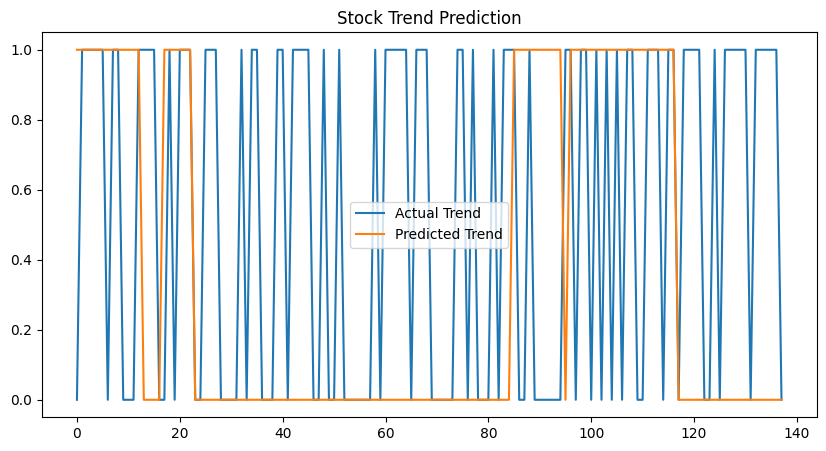

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# LOAD DATA
data = yf.download('RELIANCE.NS', start='2021-01-01', end='2024-01-01')

if data.empty:
    print("Data not loaded properly")
    exit()


# ADD FEATURE
data['Return'] = data['Close'].pct_change()
data.dropna(inplace=True)

features = data[['Close', 'Return']].values


# TRAIN-TEST SPLIT
split = int(0.8 * len(features))
train_data = features[:split]
test_data = features[split:]


# SCALING
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)


# CREATE SEQUENCES
def create_sequences(data, seq_length=10):
    X, y = [], []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(1 if data[i+seq_length][0] > data[i+seq_length-1][0] else 0)

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)


if len(X_train) == 0 or len(X_test) == 0:
    print("Not enough data. Reduce sequence length.")
    exit()


# BUILD MODEL
model = Sequential()

model.add(LSTM(64, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


# COMPILE
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# TRAIN
model.fit(X_train, y_train,
          epochs=25,
          batch_size=32,
          verbose=1)


# PREDICT
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()


# EVALUATE
print("Accuracy:", accuracy_score(y_test, y_pred))


# PLOT
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='Actual Trend')
plt.plot(y_pred, label='Predicted Trend')
plt.legend()
plt.title("Stock Trend Prediction")
plt.show()